In [1]:
from pathlib import Path
import sys
import inspect

cwd = Path.cwd().resolve()
repo_root = next(
    p for p in (cwd, *cwd.parents)
    if (p / "rebound").is_dir() and (p / "src").is_dir()
)
sys.path.insert(0, str(repo_root))


import rebound
import ctypes
import numpy as np
import matplotlib.pyplot as plt

integrate_signature = inspect.signature(rebound.Simulation.integrate)
if "given_tree" not in integrate_signature.parameters:
    raise RuntimeError(
        "This kernel loaded an old rebound module without given_tree. "
        "Restart the kernel and run this first cell again."
    )

print("rebound python:", rebound.__file__)
print("rebound library:", rebound.__libpath__)
print("integrate:", integrate_signature)


rebound python: /Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/rebound/__init__.py
rebound library: /Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/librebound.so
integrate: (self, tmax, exact_finish_time=1, given_tree=False, tree=None)


In [2]:
def beust_binary_period(a_binary=1.0, total_mass=1.0, G=1.0):
    return 2*np.pi*np.sqrt(a_binary**3/(G*total_mass))


def _sample_disk_elements(rng, n, r_range, e_range, inc_range_deg, a_binary):
    if n <= 0:
        return (np.array([]),)*6

    r_min, r_max = np.asarray(r_range, dtype=float)*a_binary
    e_min, e_max = e_range
    inc_min, inc_max = np.deg2rad(inc_range_deg)

    r = rng.uniform(r_min, r_max, n)
    ecc = rng.uniform(e_min, e_max, n)
    inc = rng.uniform(inc_min, inc_max, n)
    Omega = rng.uniform(0.0, 2*np.pi, n)
    omega = rng.uniform(0.0, 2*np.pi, n)
    f = rng.uniform(0.0, 2*np.pi, n)

    # Choose a so the initial particle position has radius r from its primary.
    semi = r*(1 + ecc*np.cos(f))/(1 - ecc**2)
    return semi, ecc, inc, Omega, omega, f


def _add_test_particle_disk(
    sim,
    primary,
    n,
    rng,
    r_range,
    e_range=(0.0, 0.1),
    inc_range_deg=(0.0, 3.0),
    a_binary=1.0,
):
    semi, ecc, inc, Omega, omega, f = _sample_disk_elements(
        rng, n, r_range, e_range, inc_range_deg, a_binary
    )

    for values in zip(semi, ecc, inc, Omega, omega, f):
        a_i, e_i, inc_i, Omega_i, omega_i, f_i = values
        sim.add(
            m=0.0,
            a=float(a_i),
            e=float(e_i),
            inc=float(inc_i),
            Omega=float(Omega_i),
            omega=float(omega_i),
            f=float(f_i),
            primary=primary,
        )


def setup_beust_system(
    mu,
    e,
    *,
    n_particles=100000, # in paper was 100000
    seed=1,
    integrator="whfast_hj",
    include_circumstellar=False,
    a_binary=1.0,
    total_mass=1.0,
    G=1.0,
    circumbinary_r=(1.5, 3.5),
    circumbinary_e=(0.0, 0.1),
    circumbinary_inc_deg=(0.0, 3.0),
    circumstellar_r=(0.05, 0.7),
):
    """Set up Beust section 3.1's binary plus test-particle disk.

    Defaults reproduce the Figure 1/Figure 2 initial condition family:
    G = M = a_binary = 1, dt = P_binary/20, and particles around the
    binary center of mass from 1.5a to 3.5a with Sigma proportional to r^-1.

    Set include_circumstellar=True for the Figure 3-style split: half the
    particles circumbinary, one quarter around each binary component.
    """
    if not (0.0 < mu < 1.0):
        raise ValueError("mu must be between 0 and 1.")
    if not (0.0 <= e < 1.0):
        raise ValueError("e must satisfy 0 <= e < 1.")
    if n_particles < 0:
        raise ValueError("n_particles must be non-negative.")

    rng = np.random.default_rng(seed)
    sim = rebound.Simulation()
    sim.G = G

    m_primary = (1.0 - mu)*total_mass
    m_secondary = mu*total_mass
    sim.add(m=m_primary, name="primary")
    sim.add(
        m=m_secondary,
        a=a_binary,
        e=e,
        inc=0.0,
        Omega=0.0,
        omega=0.0,
        f=0.0,
        primary=sim.particles[0],
        name="secondary",
    )
    primary_star = sim.particles[0].copy()
    secondary_star = sim.particles[1].copy()

    if include_circumstellar:
        n_circumbinary = n_particles//2
        n_primary_disk = (n_particles - n_circumbinary)//2
        n_secondary_disk = n_particles - n_circumbinary - n_primary_disk
    else:
        n_circumbinary = n_particles
        n_primary_disk = 0
        n_secondary_disk = 0

    binary_com = sim.com(last=2)
    _add_test_particle_disk(
        sim,
        binary_com,
        n_circumbinary,
        rng,
        circumbinary_r,
        e_range=circumbinary_e,
        inc_range_deg=circumbinary_inc_deg,
        a_binary=a_binary,
    )

    if include_circumstellar:
        _add_test_particle_disk(
            sim,
            primary_star,
            n_primary_disk,
            rng,
            circumstellar_r,
            e_range=(0.0, 0.0),
            inc_range_deg=(0.0, 0.0),
            a_binary=a_binary,
        )
        _add_test_particle_disk(
            sim,
            secondary_star,
            n_secondary_disk,
            rng,
            circumstellar_r,
            e_range=(0.0, 0.0),
            inc_range_deg=(0.0, 0.0),
            a_binary=a_binary,
        )

    sim.N_active = 2
    sim.testparticle_type = 0
    sim.move_to_com()

    if integrator is not None:
        sim.integrator = integrator
    sim.dt = beust_binary_period(a_binary, total_mass, G)/20
    return sim


# Examples:
# fig3_sim = setup_beust_system(mu=0.3, e=0.1, include_circumstellar=True)
# quick_sim = setup_beust_system(mu=0.3, e=0.1, n_particles=1000, seed=3)


In [3]:
def binary_plus_particles_tree(N):
    """Use a fixed HJ chain: first the binary, then each test particle."""
    if N < 0:
        raise ValueError("N must be non-negative.")
    if N == 0:
        return "[]"
    if N == 1:
        return "1"

    # Compact special mode handled in C. It builds the same tree as
    # [[[...[1,2],3],4],...],N] without creating/parsing that huge string.
    return "binary_plus_particles"


In [6]:
def estimate_inner_edge_radius(
    sim,
    *,
    particle_start=2,
    r_range=(0.0, 4.0),
    nbins=160,
    reference_range=(1.5, 3.5),
    reference_mode="peak",
    search_min_radius=1.5,
    threshold_fraction=0.25,
    consecutive_bins=3,
    smooth_bins=2,
    return_profile=False,
):
    """Estimate the circumbinary disk inner edge while ignoring inward outliers.

    The edge is the first radius where the smoothed radial particle count is
    above a fixed fraction of the surviving main-disk count for several bins in
    a row. This measures where the main disk begins, not the innermost particle.
    """
    if particle_start >= sim.N:
        raise ValueError("No disk particles found after particle_start.")
    if consecutive_bins < 1:
        raise ValueError("consecutive_bins must be at least 1.")

    binary_com = sim.com(last=2)
    particles = sim.particles[particle_start:]
    x = np.array([p.x - binary_com.x for p in particles])
    y = np.array([p.y - binary_com.y for p in particles])
    r = np.sqrt(x*x + y*y)

    counts, edges = np.histogram(r, bins=nbins, range=r_range)
    centers = 0.5*(edges[:-1] + edges[1:])

    if smooth_bins > 0:
        width = 2*smooth_bins + 1
        kernel = np.ones(width)/width
        smooth_counts = np.convolve(counts, kernel, mode="same")
    else:
        smooth_counts = counts.astype(float)

    ref_mask = (centers >= reference_range[0]) & (centers <= reference_range[1])
    positive_ref = smooth_counts[ref_mask & (smooth_counts > 0)]
    positive_counts = smooth_counts[smooth_counts > 0]

    if reference_mode == "peak":
        # High-eccentricity binaries can clear material even near 3a. Using the
        # strongest surviving disk bins avoids lowering the threshold inside the gap.
        reference_count = np.percentile(positive_ref, 90) if positive_ref.size else 0.0
    elif reference_mode == "median":
        reference_count = np.median(positive_ref) if positive_ref.size else 0.0
    else:
        raise ValueError('reference_mode must be "peak" or "median".')

    if reference_count <= 0 and positive_counts.size:
        reference_count = np.percentile(positive_counts, 90)

    threshold = threshold_fraction*reference_count
    above = (smooth_counts >= threshold) & (centers >= search_min_radius)

    edge_radius = np.nan
    for i in range(0, len(above) - consecutive_bins + 1):
        if np.all(above[i:i + consecutive_bins]):
            edge_radius = centers[i]
            break

    if not return_profile:
        return edge_radius

    return {
        "edge_radius": edge_radius,
        "r": r,
        "bin_centers": centers,
        "counts": counts,
        "smooth_counts": smooth_counts,
        "threshold": threshold,
        "reference_count": reference_count,
        "reference_mode": reference_mode,
        "search_min_radius": search_min_radius,
    }


fixed HJ tree mode: binary_plus_particles, N = 100002


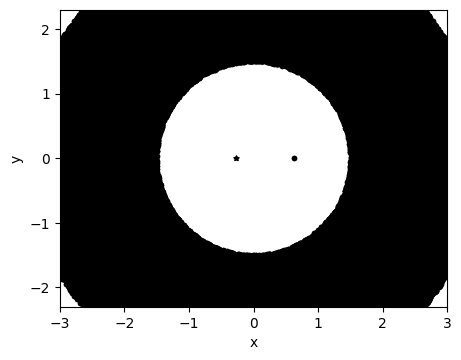

In [7]:
fig1_sim = setup_beust_system(mu=0.3, e=0.1)
fig1_tree = binary_plus_particles_tree(fig1_sim.N)
print(f"fixed HJ tree mode: {fig1_tree}, N = {fig1_sim.N}")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)


T = 0.55 binary periods


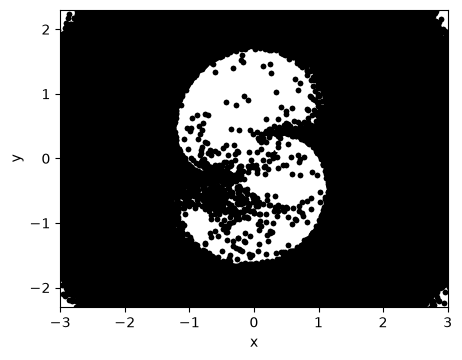

In [7]:
P_binary = beust_binary_period()
fig1_sim.integrator="whfast_hj"
fig1_sim.integrate(
    0.55*P_binary,
    exact_finish_time=0,
    given_tree=True,
    tree=fig1_tree,
)
print(f"T = {fig1_sim.t/P_binary:.2f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)


T = 3.05 binary periods


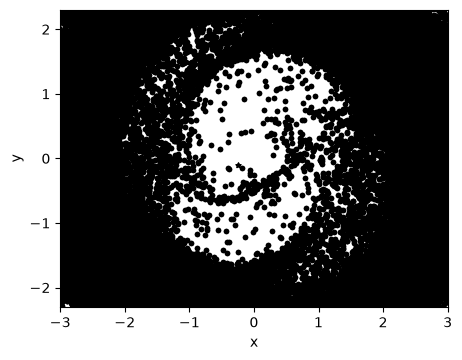

In [8]:
P_binary = beust_binary_period()
fig1_sim.integrator="whfast_hj"
fig1_sim.integrate(
    3.05*P_binary,
    exact_finish_time=0,
    given_tree=True,
    tree=fig1_tree,
)
print(f"T = {fig1_sim.t/P_binary:.2f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)


T = 30.05 binary periods


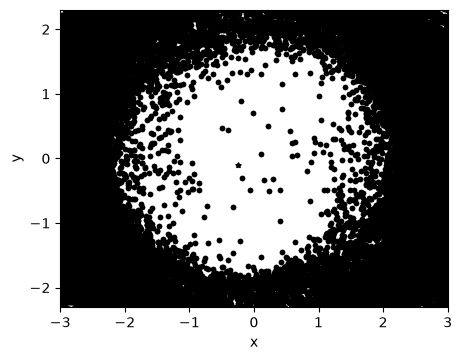

In [9]:
P_binary = beust_binary_period()

fig1_sim.integrator="whfast_hj"
fig1_sim.integrate(
    30.0*P_binary,
    exact_finish_time=0,
    given_tree=True,
    tree=fig1_tree,
)
print(f"T = {fig1_sim.t/P_binary:.2f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)


T = 300 binary periods


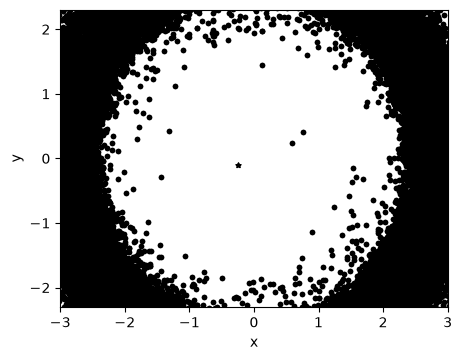

In [10]:
P_binary = beust_binary_period()
fig1_sim.integrator="whfast_hj"
fig1_sim.integrate(
    300*P_binary,
    exact_finish_time=0,
    given_tree=True,
    tree=fig1_tree,
)
print(f"T = {fig1_sim.t/P_binary:.0f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)


T = 100000 binary periods


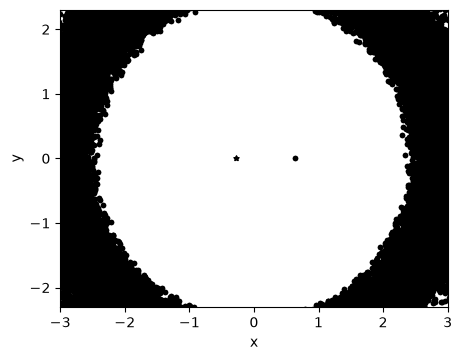

In [11]:
P_binary = beust_binary_period()
fig1_sim.integrator="whfast_hj"
fig1_sim.integrate(
    100000*P_binary,
    exact_finish_time=0,
    given_tree=True,
    tree=fig1_tree,
)
print(f"T = {fig1_sim.t/P_binary:.0f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)


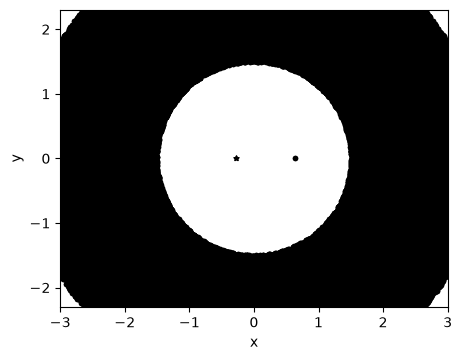

In [12]:
fig1_sim = setup_beust_system(mu=0.3, e=0.1)

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)

T = 0.60 binary periods


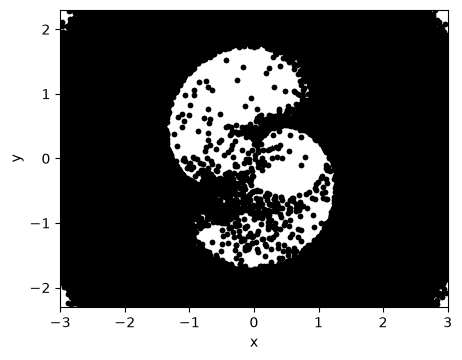

In [13]:
P_binary = beust_binary_period()
fig1_sim.integrator="whfast"
fig1_sim.integrate(
    0.55*P_binary,
    exact_finish_time=0
)
print(f"T = {fig1_sim.t/P_binary:.2f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)


T = 3.05 binary periods


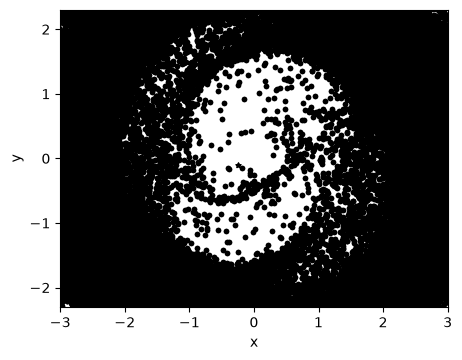

In [14]:
P_binary = beust_binary_period()
fig1_sim.integrator="whfast"
fig1_sim.integrate(
    3.05*P_binary,
    exact_finish_time=0
)
print(f"T = {fig1_sim.t/P_binary:.2f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)

T = 30.05 binary periods


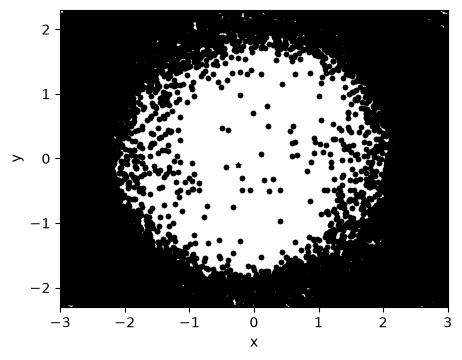

In [15]:
P_binary = beust_binary_period()
fig1_sim.integrator="whfast"
fig1_sim.integrate(
    30.0*P_binary,
    exact_finish_time=0
)
print(f"T = {fig1_sim.t/P_binary:.2f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)

T = 300.00 binary periods


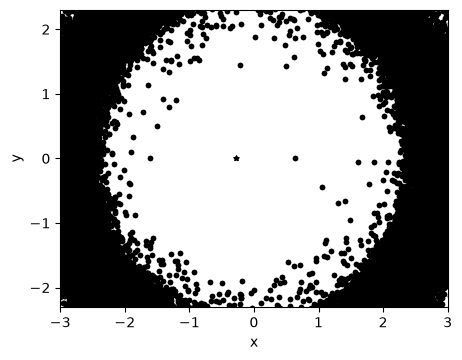

In [16]:
P_binary = beust_binary_period()
fig1_sim.integrator="whfast"
fig1_sim.integrate(
    300*P_binary,
    exact_finish_time=0
)
print(f"T = {fig1_sim.t/P_binary:.2f} binary periods")

rebound.OrbitPlot(
    fig1_sim,
    orbit_style=None,
    xlim=(-3, 3),
    ylim=(-2.3, 2.3),
    lw=0.35,
)

In [ ]:
fig2_mu_values = [0.1, 0.3]
fig2_e_values = np.array([0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99])
fig2_n_particles = 100000
fig2_target_periods = 300
fig2_seed = 1
fig2_integrator = "whfast_hj"

P_binary = beust_binary_period()
fig2_results = []

for mu in fig2_mu_values:
    for e in fig2_e_values:
        sim = setup_beust_system(
            mu=mu,
            e=e,
            n_particles=fig2_n_particles,
            seed=fig2_seed,
            integrator=fig2_integrator,
        )
        tree = binary_plus_particles_tree(sim.N)
        sim.integrate(
            fig2_target_periods*P_binary,
            exact_finish_time=0,
            given_tree=True,
            tree=tree,
        )
        edge_radius = estimate_inner_edge_radius(sim)
        fig2_results.append({"mu": mu, "e": e, "edge_radius": edge_radius})
        print(f"mu={mu:.2f}, e={e:.2f}, edge={edge_radius:.3f}")

mu=0.10, e=0.00, edge=1.788
mu=0.10, e=0.05, edge=2.013


In [ ]:
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

fig, ax = plt.subplots(figsize=(7.2, 4.8))

for mu in fig2_mu_values:
    rows = [row for row in fig2_results if np.isclose(row["mu"], mu)]
    rows = sorted(rows, key=lambda row: row["e"])

    e_vals = [row["e"] for row in rows]
    edge_vals = [row["edge_radius"] for row in rows]

    if np.isclose(mu, 0.1):
        markerfacecolor = "white"
    else:
        markerfacecolor = "black"

    ax.plot(
        e_vals,
        edge_vals,
        color="black",
        linestyle=(0, (1.5, 2.2)),
        linewidth=0.8,
        marker="o",
        markersize=7.5,
        markerfacecolor=markerfacecolor,
        markeredgecolor="black",
        markeredgewidth=0.9,
        label=fr"$\mu\ =\ {mu:.1f}$",
    )

ax.set_xlim(0.0, 1.0)
ax.set_ylim(1.5, 4.0)
ax.set_xticks(np.linspace(0.0, 1.0, 6))
ax.set_yticks(np.arange(1.5, 4.01, 0.5))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:g}"))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_xlabel("Orbital eccentricity", fontsize=18, fontfamily="serif")
ax.set_ylabel("Gap radius / semi-major axis", fontsize=18, fontfamily="serif")
ax.tick_params(which="major", direction="in", top=True, right=True, length=8, labelsize=15)
ax.tick_params(which="minor", direction="in", top=True, right=True, length=4)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("serif")

ax.legend(
    loc="lower right",
    frameon=False,
    prop={"family": "serif", "size": 16},
    handlelength=2.2,
)
fig.tight_layout()
plt.show()


In [ ]:
# this is to confirm that  mu = e = 0.1 is problmatic.
P_binary = beust_binary_period()
sim = setup_beust_system(
    mu=0.1,
    e=0.1,
)
sim.integrator="whfast_hj"

tree = binary_plus_particles_tree(sim.N)
sim.integrate(
    300*P_binary,
    exact_finish_time=0,
    given_tree=True,
    tree=tree,
)
edge_radius = estimate_inner_edge_radius(sim)
print(edge_radius)